# 1. DEFINING THE PROBLEM

You’re given a dataset of Starcraft player performance data in ranked games. We want to develop a model to predict a player’s rank using the information provided in the dataset.

**Language:** Python 

In [1]:
import pandas as pd
import numpy as np

# Dat Cleaning
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Data Visualizations 
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Import necessary libraries for model training and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 2. READING DATA SET

In [2]:
#load the csv file
df = pd.read_csv("starcraft_player_data.csv") 
#check first 5 rows
df.head()

,GameID,LeagueIndex,Age,HoursPerWeek,TotalHours,APM,SelectByHotkeys,AssignToHotkeys,UniqueHotkeys,MinimapAttacks,MinimapRightClicks,NumberOfPACs,GapBetweenPACs,ActionLatency,ActionsInPAC,TotalMapExplored,WorkersMade,UniqueUnitsMade,ComplexUnitsMade,ComplexAbilitiesUsed
0,52,5,27,10,3000,143.7180,0.003515,0.000220,7,0.000110,0.000392,0.004849,32.6677,40.8673,4.7508,28,0.001397,6,0.0,0.000000
1,55,5,23,10,5000,129.2322,0.003304,0.000259,4,0.000294,0.000432,0.004307,32.9194,42.3454,4.8434,22,0.001193,5,0.0,0.000208
2,56,4,30,10,200,69.9612,0.001101,0.000336,4,0.000294,0.000461,0.002926,44.6475,75.3548,4.0430,22,0.000745,6,0.0,0.000189
3,57,3,19,20,400,107.6016,0.001034,0.000213,1,0.000053,0.000543,0.003783,29.2203,53.7352,4.9155,19,0.000426,7,0.0,0.000384
4,58,3,32,10,500,122.8908,0.001136,0.000327,2,0.000000,0.001329,0.002368,22.6885,62.0813,9.3740,15,0.001174,4,0.0,0.000019


## Data Integrity Check

In [3]:
#Summary info about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3395 entries, 0 to 3394
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GameID                3395 non-null   int64  
 1   LeagueIndex           3395 non-null   int64  
 2   Age                   3395 non-null   object 
 3   HoursPerWeek          3395 non-null   object 
 4   TotalHours            3395 non-null   object 
 5   APM                   3395 non-null   float64
 6   SelectByHotkeys       3395 non-null   float64
 7   AssignToHotkeys       3395 non-null   float64
 8   UniqueHotkeys         3395 non-null   int64  
 9   MinimapAttacks        3395 non-null   float64
 10  MinimapRightClicks    3395 non-null   float64
 11  NumberOfPACs          3395 non-null   float64
 12  GapBetweenPACs        3395 non-null   float64
 13  ActionLatency         3395 non-null   float64
 14  ActionsInPAC          3395 non-null   float64
 15  TotalMapExplored     

**Key Takeaways:**
1. 3,395 rows and 20 columns
2. LeagueIndex is the Target variable and represents the players rank (Ordinal)
3. Data Types: Age, HoursPerWeek, and TotalHours are objects but these categories should be numeric.
5. Non-Null Count shows there is no missing values but this would need to be further inspected because of the previous point.
6. GameID just seems like a unique identifier and may not be valuable for model training

**To-Do:**
1. Check for missing data 
2. Convert the object types into numeric

In [4]:
# Check for missing values in non-numeric columns
unique_values = {col: df[col].unique() 
                 for col in df.select_dtypes(include=["object"]).columns}

unique_values

{'Age': array(['27', '23', '30', '19', '32', '21', '17', '20', '18', '16', '26',
        '38', '28', '25', '22', '29', '24', '35', '31', '33', '37', '40',
        '34', '43', '41', '36', '44', '39', '?'], dtype=object),
 'HoursPerWeek': array(['10', '20', '6', '8', '42', '14', '24', '16', '4', '12', '30',
        '28', '70', '2', '56', '36', '40', '18', '96', '50', '168', '48',
        '84', '0', '72', '112', '90', '32', '98', '140', '?', '80', '60'],
       dtype=object),
 'TotalHours': array(['3000', '5000', '200', '400', '500', '70', '240', '10000', '2708',
        '800', '6000', '190', '350', '1000', '1500', '2000', '120', '1100',
        '2520', '700', '160', '150', '250', '730', '230', '300', '100',
        '270', '1200', '30', '600', '540', '280', '1600', '50', '140',
        '900', '550', '625', '1300', '450', '750', '612', '180', '770',
        '720', '415', '1800', '2200', '480', '430', '639', '360', '1250',
        '365', '650', '233', '416', '1825', '780', '1260', '315', '1

**Key TakeAway:**
1. we can see that there are '?' in place of missing inputs
2. This would nned to be handled before converting the dtype

In [5]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

In [6]:
# Convert Dtype from object to int
df[['Age', 'HoursPerWeek', 'TotalHours']] = df[['Age', 'HoursPerWeek', 'TotalHours']].apply(pd.to_numeric)


#confirming changes
df.info()

# Checking for Missing values after conversion

print("\nNumber of nulls \n")
print(df.isnull().sum())

# Percentage of missing values per column
(df.isnull().sum()/(len(df)))*100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3395 entries, 0 to 3394
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GameID                3395 non-null   int64  
 1   LeagueIndex           3395 non-null   int64  
 2   Age                   3340 non-null   float64
 3   HoursPerWeek          3339 non-null   float64
 4   TotalHours            3338 non-null   float64
 5   APM                   3395 non-null   float64
 6   SelectByHotkeys       3395 non-null   float64
 7   AssignToHotkeys       3395 non-null   float64
 8   UniqueHotkeys         3395 non-null   int64  
 9   MinimapAttacks        3395 non-null   float64
 10  MinimapRightClicks    3395 non-null   float64
 11  NumberOfPACs          3395 non-null   float64
 12  GapBetweenPACs        3395 non-null   float64
 13  ActionLatency         3395 non-null   float64
 14  ActionsInPAC          3395 non-null   float64
 15  TotalMapExplored     

GameID                  0.000000
LeagueIndex             0.000000
Age                     1.620029
HoursPerWeek            1.649485
TotalHours              1.678940
APM                     0.000000
SelectByHotkeys         0.000000
AssignToHotkeys         0.000000
UniqueHotkeys           0.000000
MinimapAttacks          0.000000
MinimapRightClicks      0.000000
NumberOfPACs            0.000000
GapBetweenPACs          0.000000
ActionLatency           0.000000
ActionsInPAC            0.000000
TotalMapExplored        0.000000
WorkersMade             0.000000
UniqueUnitsMade         0.000000
ComplexUnitsMade        0.000000
ComplexAbilitiesUsed    0.000000
dtype: float64

### HANDLING MISSING VALUES

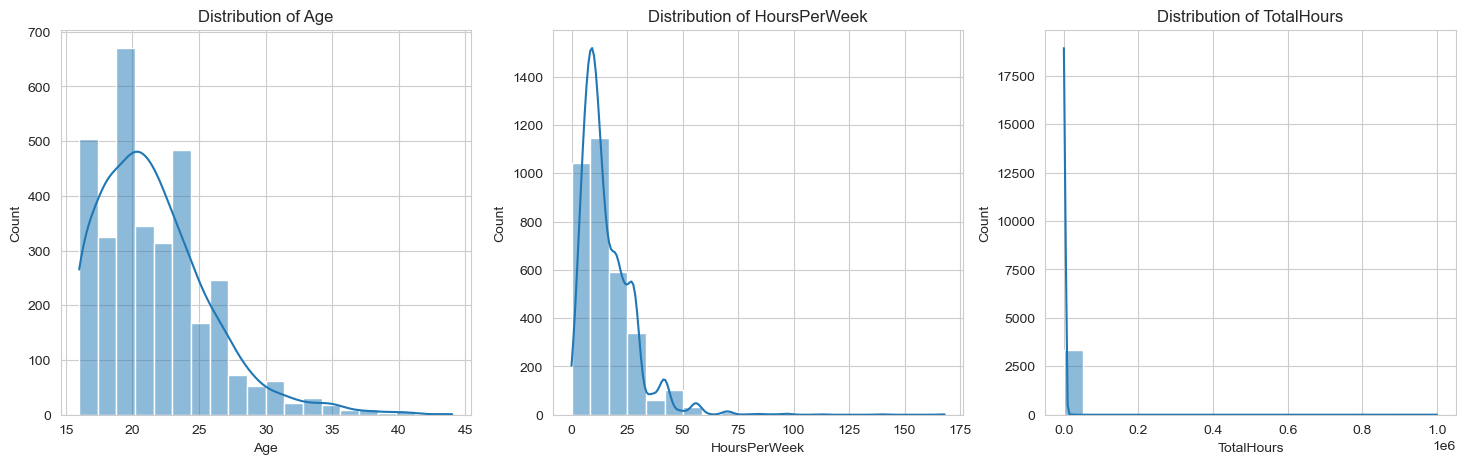

In [7]:
# Set plot style
sns.set_style("whitegrid")

# Create subplots for distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot distributions
sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Age")

sns.histplot(df["HoursPerWeek"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Distribution of HoursPerWeek")

sns.histplot(df["TotalHours"], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Distribution of TotalHours")

plt.show()

<Axes: >

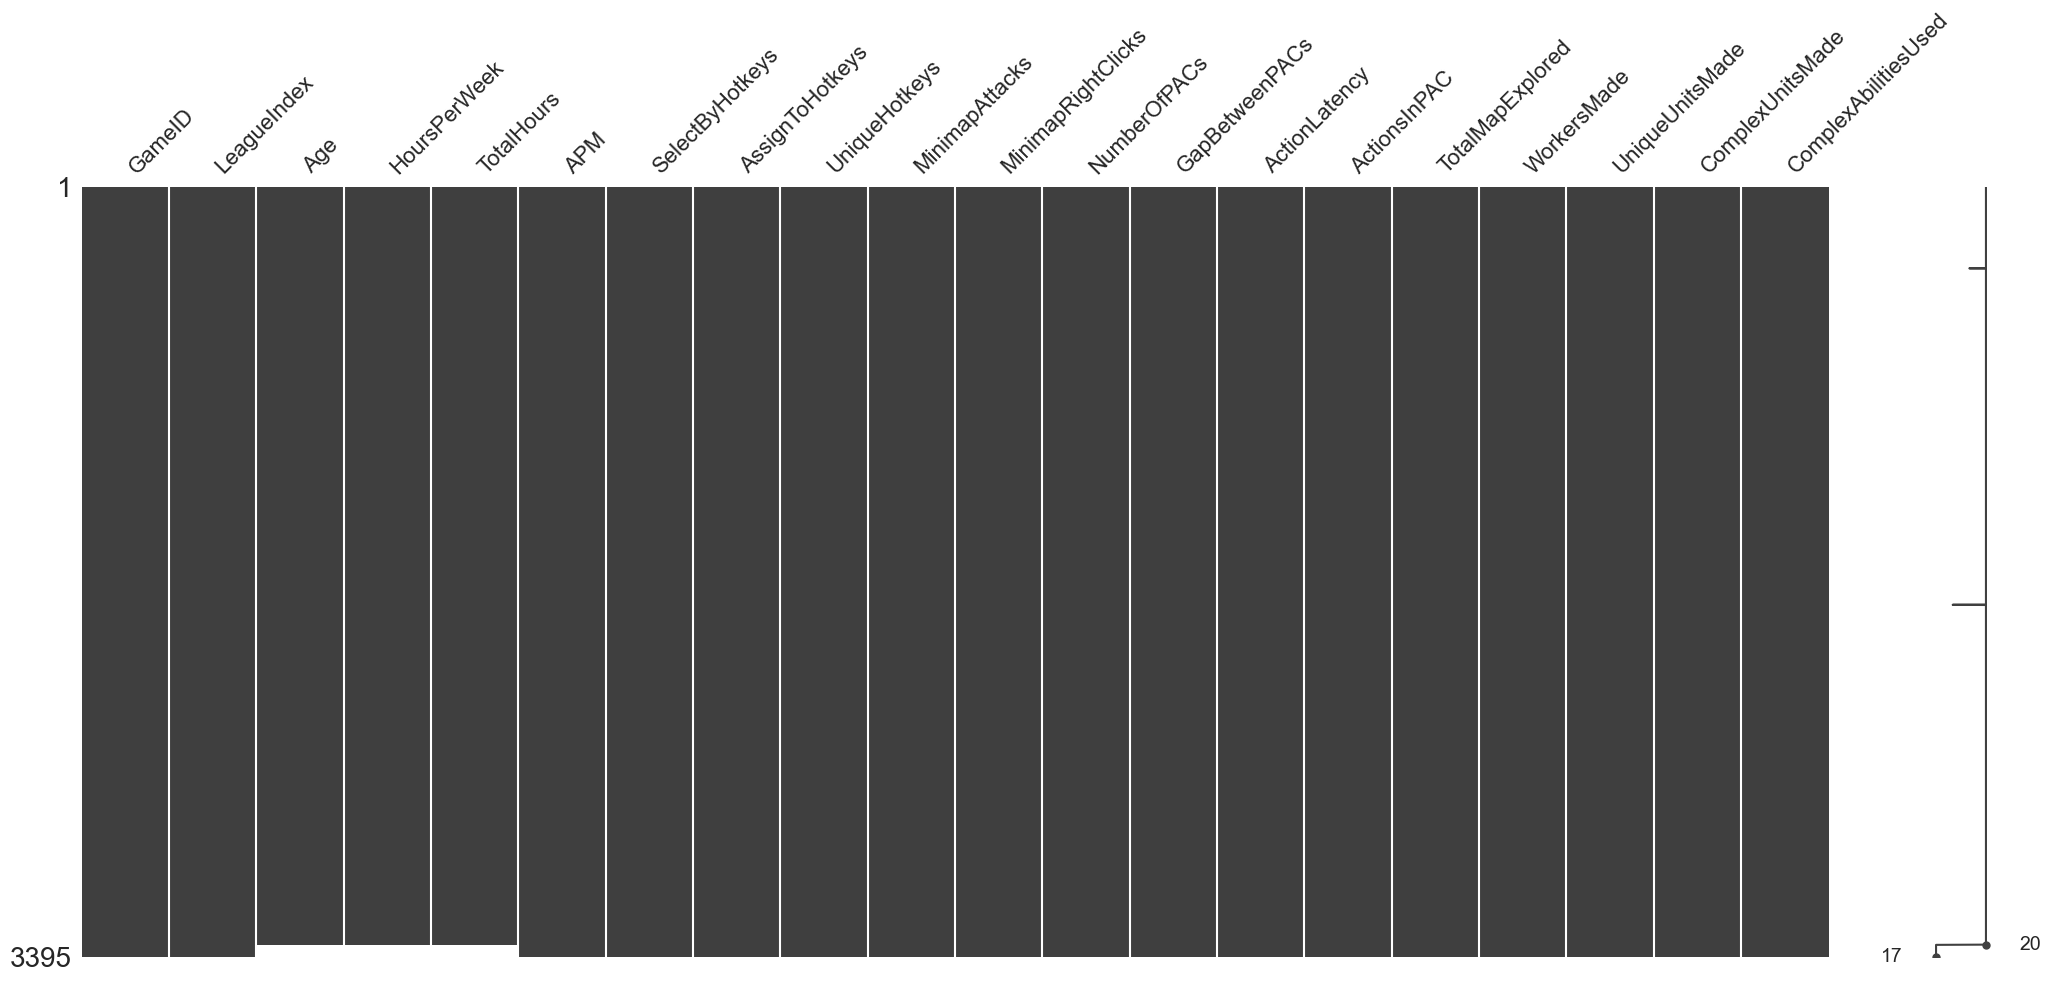

In [8]:
# Matrix to analyze any patterns in missing data
msno.matrix(df)

**Key Takeaways:**
By using this matrix chart and the histogram distribution I am able to see that the missing data is MAR and heavily right-skewed. 

This means the most effective approach would be to impute the missing column values with its median.

In [9]:
# Fill missing values with median
df["Age"].fillna(df["Age"].median(), inplace=True)
df["HoursPerWeek"].fillna(df["HoursPerWeek"].median(), inplace=True)
df["TotalHours"].fillna(df["TotalHours"].median(), inplace=True)

# Confirm that there are no more missing values
print(df.isnull().sum())

GameID                  0
LeagueIndex             0
Age                     0
HoursPerWeek            0
TotalHours              0
APM                     0
SelectByHotkeys         0
AssignToHotkeys         0
UniqueHotkeys           0
MinimapAttacks          0
MinimapRightClicks      0
NumberOfPACs            0
GapBetweenPACs          0
ActionLatency           0
ActionsInPAC            0
TotalMapExplored        0
WorkersMade             0
UniqueUnitsMade         0
ComplexUnitsMade        0
ComplexAbilitiesUsed    0
dtype: int64


In [10]:
# Check for duplicates
duplicate_count = df.duplicated().sum()
print("Number of duplicates:", duplicate_count)

# Drop duplicates if any
df = df.drop_duplicates()

print("Number of duplicates removed:", {duplicate_count})
print('\n')

Number of duplicates: 0
Number of duplicates removed: {0}




# 3. EXPLORATORY DATA ANALYSIS (EDA)

## Univariate Analysis

In [11]:
# Summary stats of updated dataset
df.describe()

,GameID,LeagueIndex,Age,HoursPerWeek,TotalHours,APM,SelectByHotkeys,AssignToHotkeys,UniqueHotkeys,MinimapAttacks,MinimapRightClicks,NumberOfPACs,GapBetweenPACs,ActionLatency,ActionsInPAC,TotalMapExplored,WorkersMade,UniqueUnitsMade,ComplexUnitsMade,ComplexAbilitiesUsed
count,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000
mean,4805.012371,4.184094,21.637408,15.846244,952.691605,117.046947,0.004299,0.000374,4.364654,0.000098,0.000387,0.003463,40.361562,63.739403,5.272988,22.131664,0.001032,6.534021,0.000059,0.000142
std,2719.944851,1.517327,4.172921,11.874264,17172.196750,51.945291,0.005284,0.000225,2.360333,0.000166,0.000377,0.000992,17.153570,19.238869,1.494835,7.431719,0.000519,1.857697,0.000111,0.000265
min,52.000000,1.000000,16.000000,0.000000,3.000000,22.059600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000679,6.666700,24.093600,2.038900,5.000000,0.000077,2.000000,0.000000,0.000000
25%,2464.500000,3.000000,19.000000,8.000000,300.000000,79.900200,0.001258,0.000204,3.000000,0.000000,0.000140,0.002754,28.957750,50.446600,4.272850,17.000000,0.000683,5.000000,0.000000,0.000000
50%,4874.000000,4.000000,21.000000,12.000000,500.000000,108.010200,0.002500,0.000353,4.000000,0.000040,0.000281,0.003395,36.723500,60.931800,5.095500,22.000000,0.000905,6.000000,0.000000,0.000020
75%,7108.500000,5.000000,24.000000,20.000000,800.000000,142.790400,0.005133,0.000499,6.000000,0.000119,0.000514,0.004027,48.290500,73.681300,6.033600,27.000000,0.001259,8.000000,0.000086,0.000181
max,10095.000000,8.000000,44.000000,168.000000,1000000.000000,389.831400,0.043088,0.001752,10.000000,0.003019,0.004041,0.007971,237.142900,176.372100,18.558100,58.000000,0.005149,13.000000,0.000902,0.003084


**Key Takeaways:**
1. LeagueIndex ranges from 1-8, making this a cateforical ranking system
2. Age is between 16 to 44 (median:21)
3. HoursPerWeek has a big variety, meaning there is possible outliers
4. Total hours also has a big range meaning there are existing outliers, also 1,000,000 is an impossible number
5. APM range is 22 to 389 and can indicate that highly skilled players act faster
6. SelectBy and AssignTo Hotkeys have very small values and could need rescaling 
7. Other columns with low average can check for importance to ranking

4    811
5    806
6    621
3    553
2    347
1    167
8     55
7     35
Name: LeagueIndex, dtype: int64


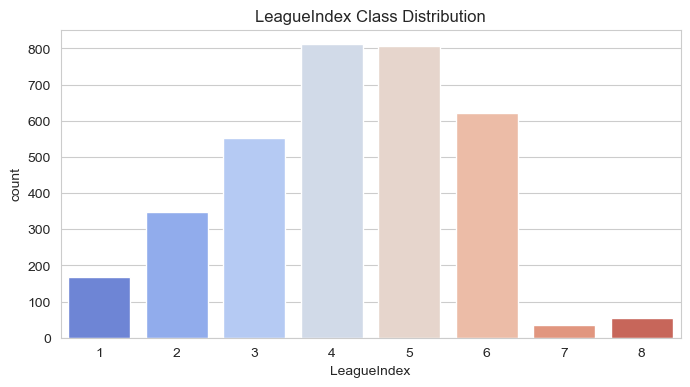

In [12]:
# Disctibution of Target Variable
print(df["LeagueIndex"].value_counts())

# Visualizing imbalance
plt.figure(figsize=(8, 4))
sns.countplot(x=df["LeagueIndex"], palette="coolwarm")
plt.title("LeagueIndex Class Distribution")
plt.show()

**Key Take Aways:**
There is very little data on the higher rankings which can effect the predictions

### Boxplot

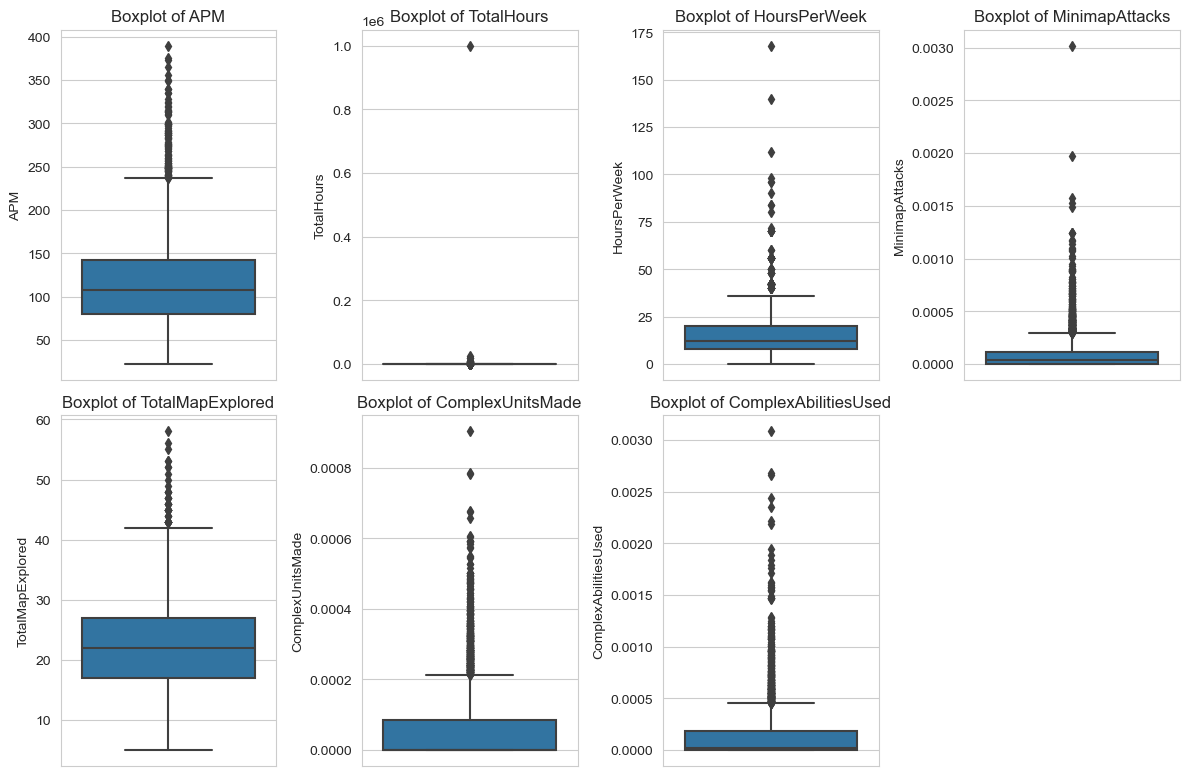

In [13]:
# Generate boxplots to detect outliers based on distribution
key_features = ["APM", "TotalHours", "HoursPerWeek", "MinimapAttacks", "TotalMapExplored", "ComplexUnitsMade", "ComplexAbilitiesUsed"]
plt.figure(figsize=(12, 8))

for i, feature in enumerate(key_features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[feature])
    plt.title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()

**Key Takeaways:**
1. **Extreme Outliers:** As mentioned before, some players in **TotalHours** have over 1,000,000 total hours, which is unrealistic. **HoursPerWeek** has extreme values up to 168 hours/week (unrealistic 24/7 playtime).

2. APM (Actions Per Minute): Some players have extremely high APM (>350), which may be valid but should be examined.

3. MinimapAttacks & TotalMapExplored: Outliers are present but less extreme than playtime features.

### Histogram 

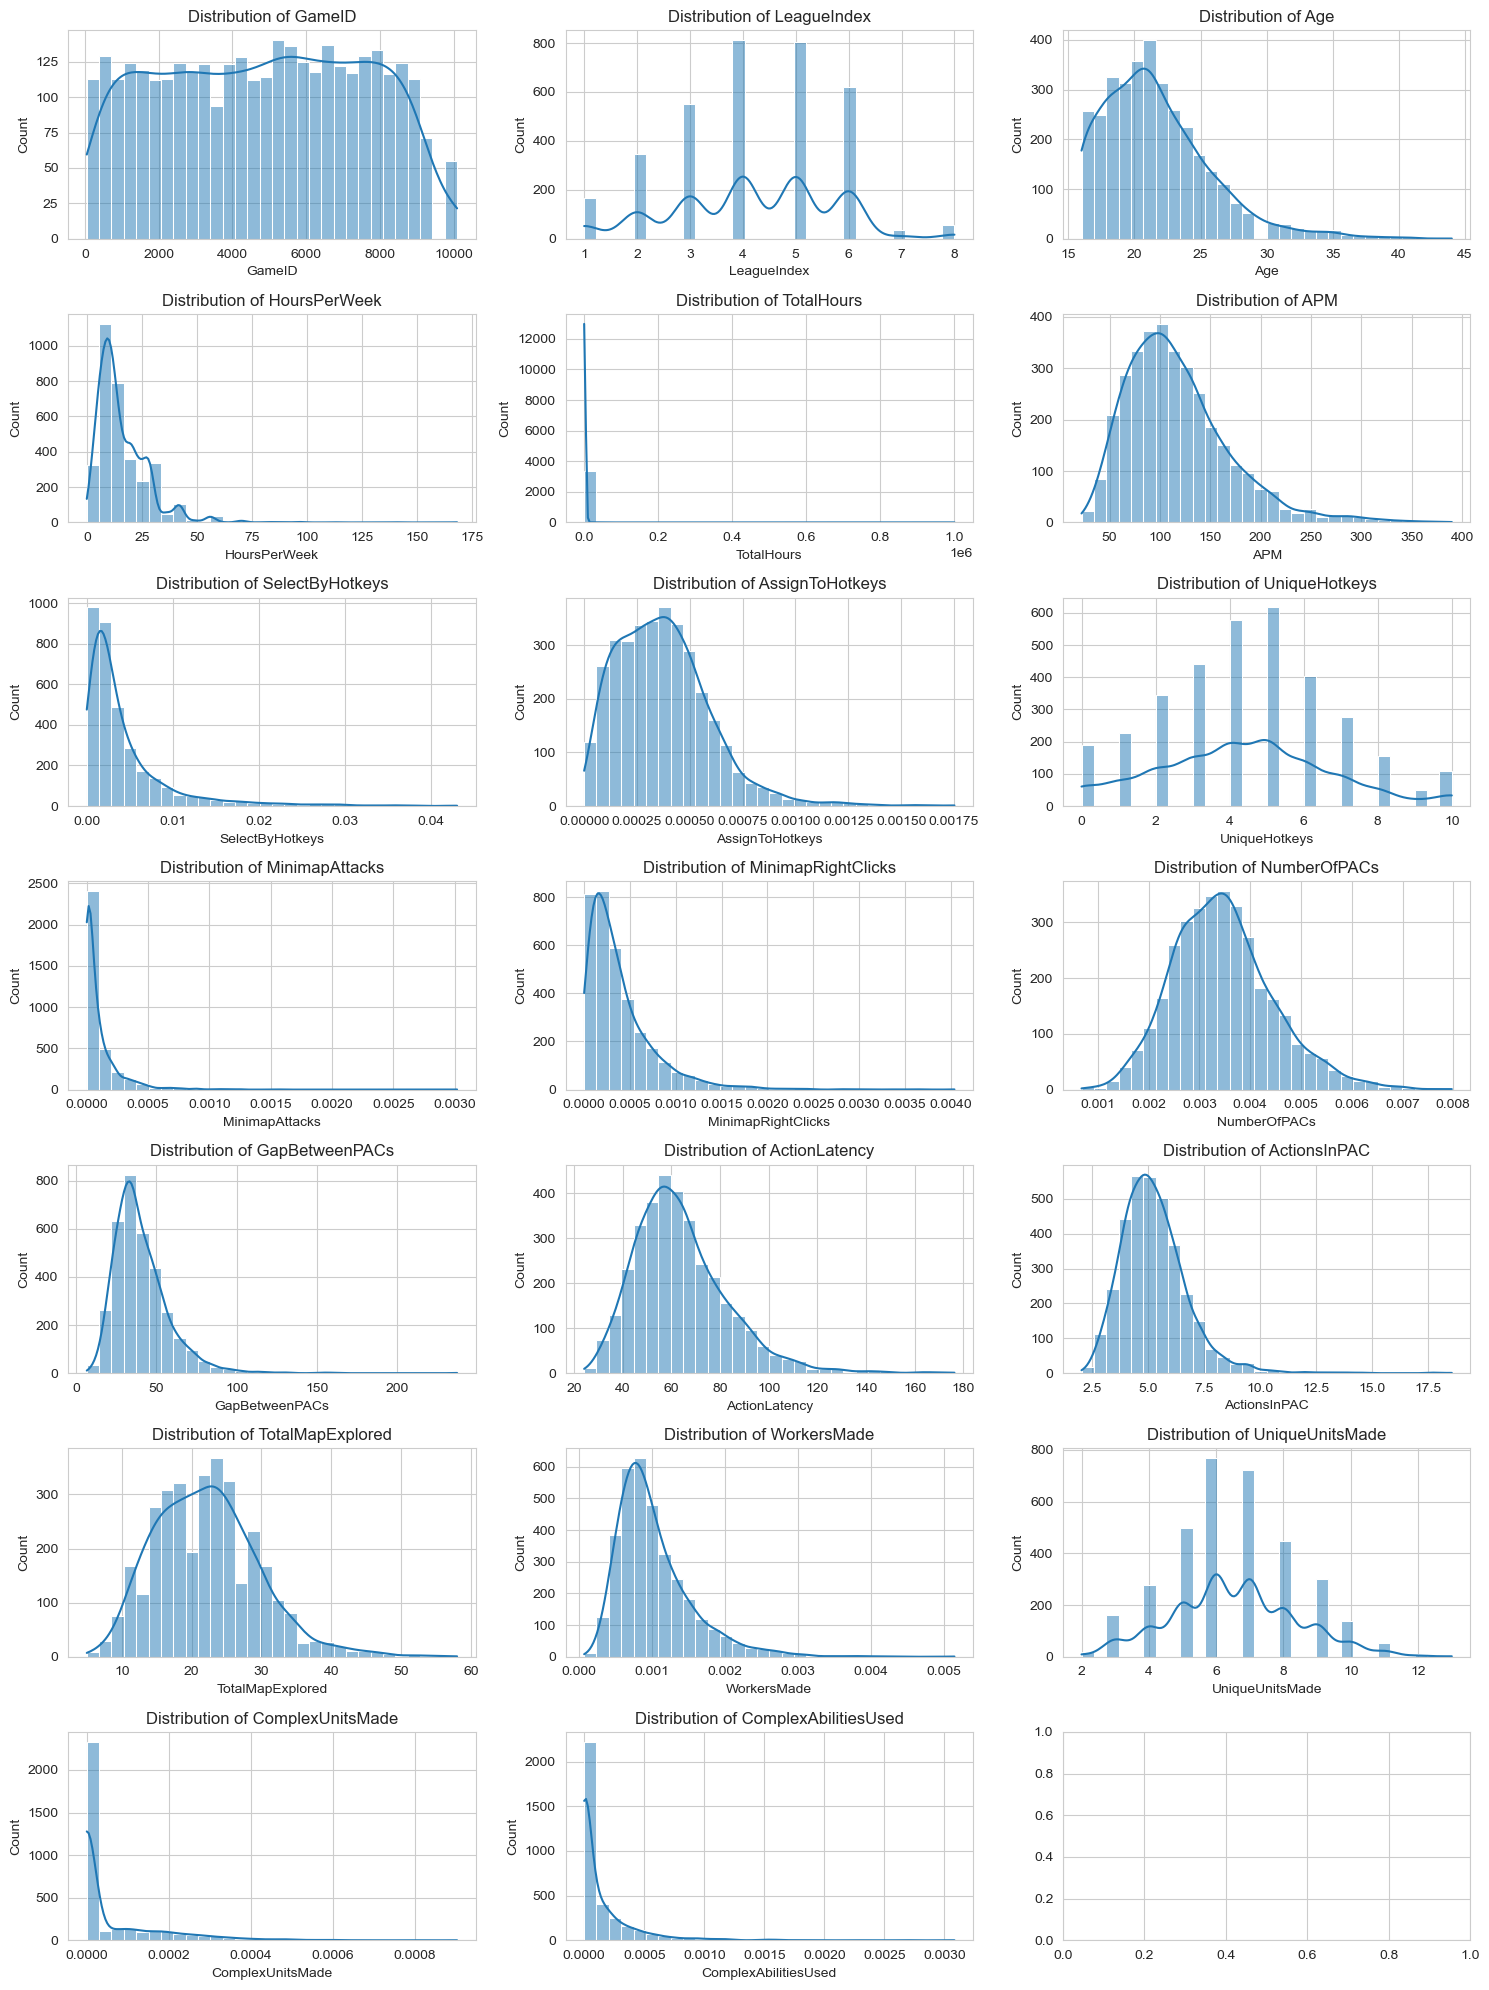

In [15]:
cols = df.columns 

# Create subplots
fig, axes = plt.subplots(len(cols) // 3 + 1, 3, figsize=(15, 20))
axes = axes.flatten()

# Plot histograms and boxplots
for i, col in enumerate(cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

**Key Takeaways:**

1. **Skewed Distributions:** Some features are heavily right-skewed, indicating extreme values and potential outliers. 

2. **Value Ranges:** Columns dealing with Minimap and hotkey usage have very small values and might require scaling.


### Outlier Handling
Based on the findings I will be dealing with the outliers by percentile capping (trimming values beyond the 99th percentile. These outliers seem mostly due to entry mistakes. This would modify extreme values by replacing them with predefined threshold values.

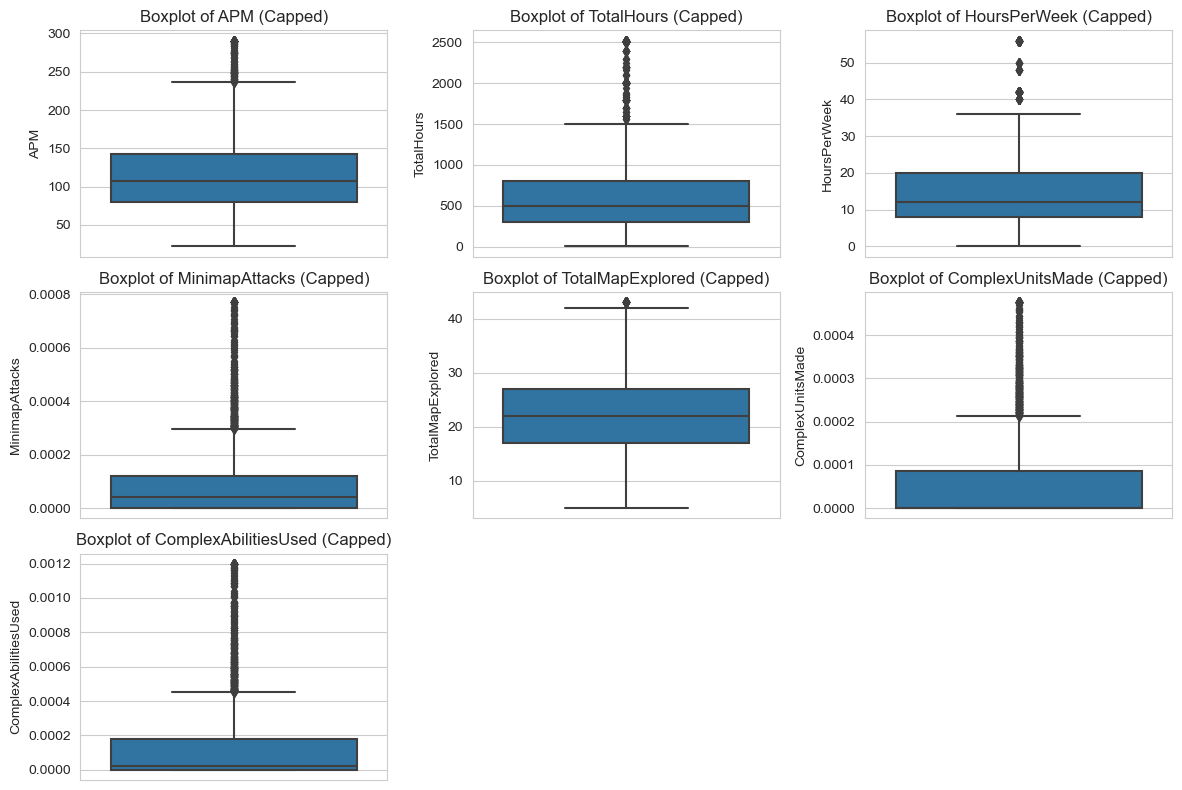

In [18]:
# Define capping function (99th percentile)
def cap_outliers(df, columns, percentile=0.99):
    for col in columns:
        upper_limit = df[col].quantile(percentile)
        df[col] = df[col].clip(upper=upper_limit)
    return df

# Apply capping to selected features
outlier_cols = [
    "APM", "TotalHours", "HoursPerWeek", "MinimapAttacks", "TotalMapExplored", "ComplexUnitsMade", "ComplexAbilitiesUsed"
] 
df = cap_outliers(df, outlier_cols)

# Verify changes with new boxplots
plt.figure(figsize=(12, 8))
for i, feature in enumerate(outlier_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y= df[feature])
    plt.title(f"Boxplot of {feature} (Capped)")

plt.tight_layout()
plt.show()

### Log Transformation
Done on skewed features to help normalize the data

In [19]:
### Apply Log Transformation for Skewed Features
skewed_cols = ["TotalHours", "HoursPerWeek", "APM", "MinimapAttacks", "ComplexUnitsMade", "ComplexAbilitiesUsed"]  
for col in skewed_cols:
    df[col] = np.log1p(df[col])  # log1p(x) = log(x + 1) to handle zero values

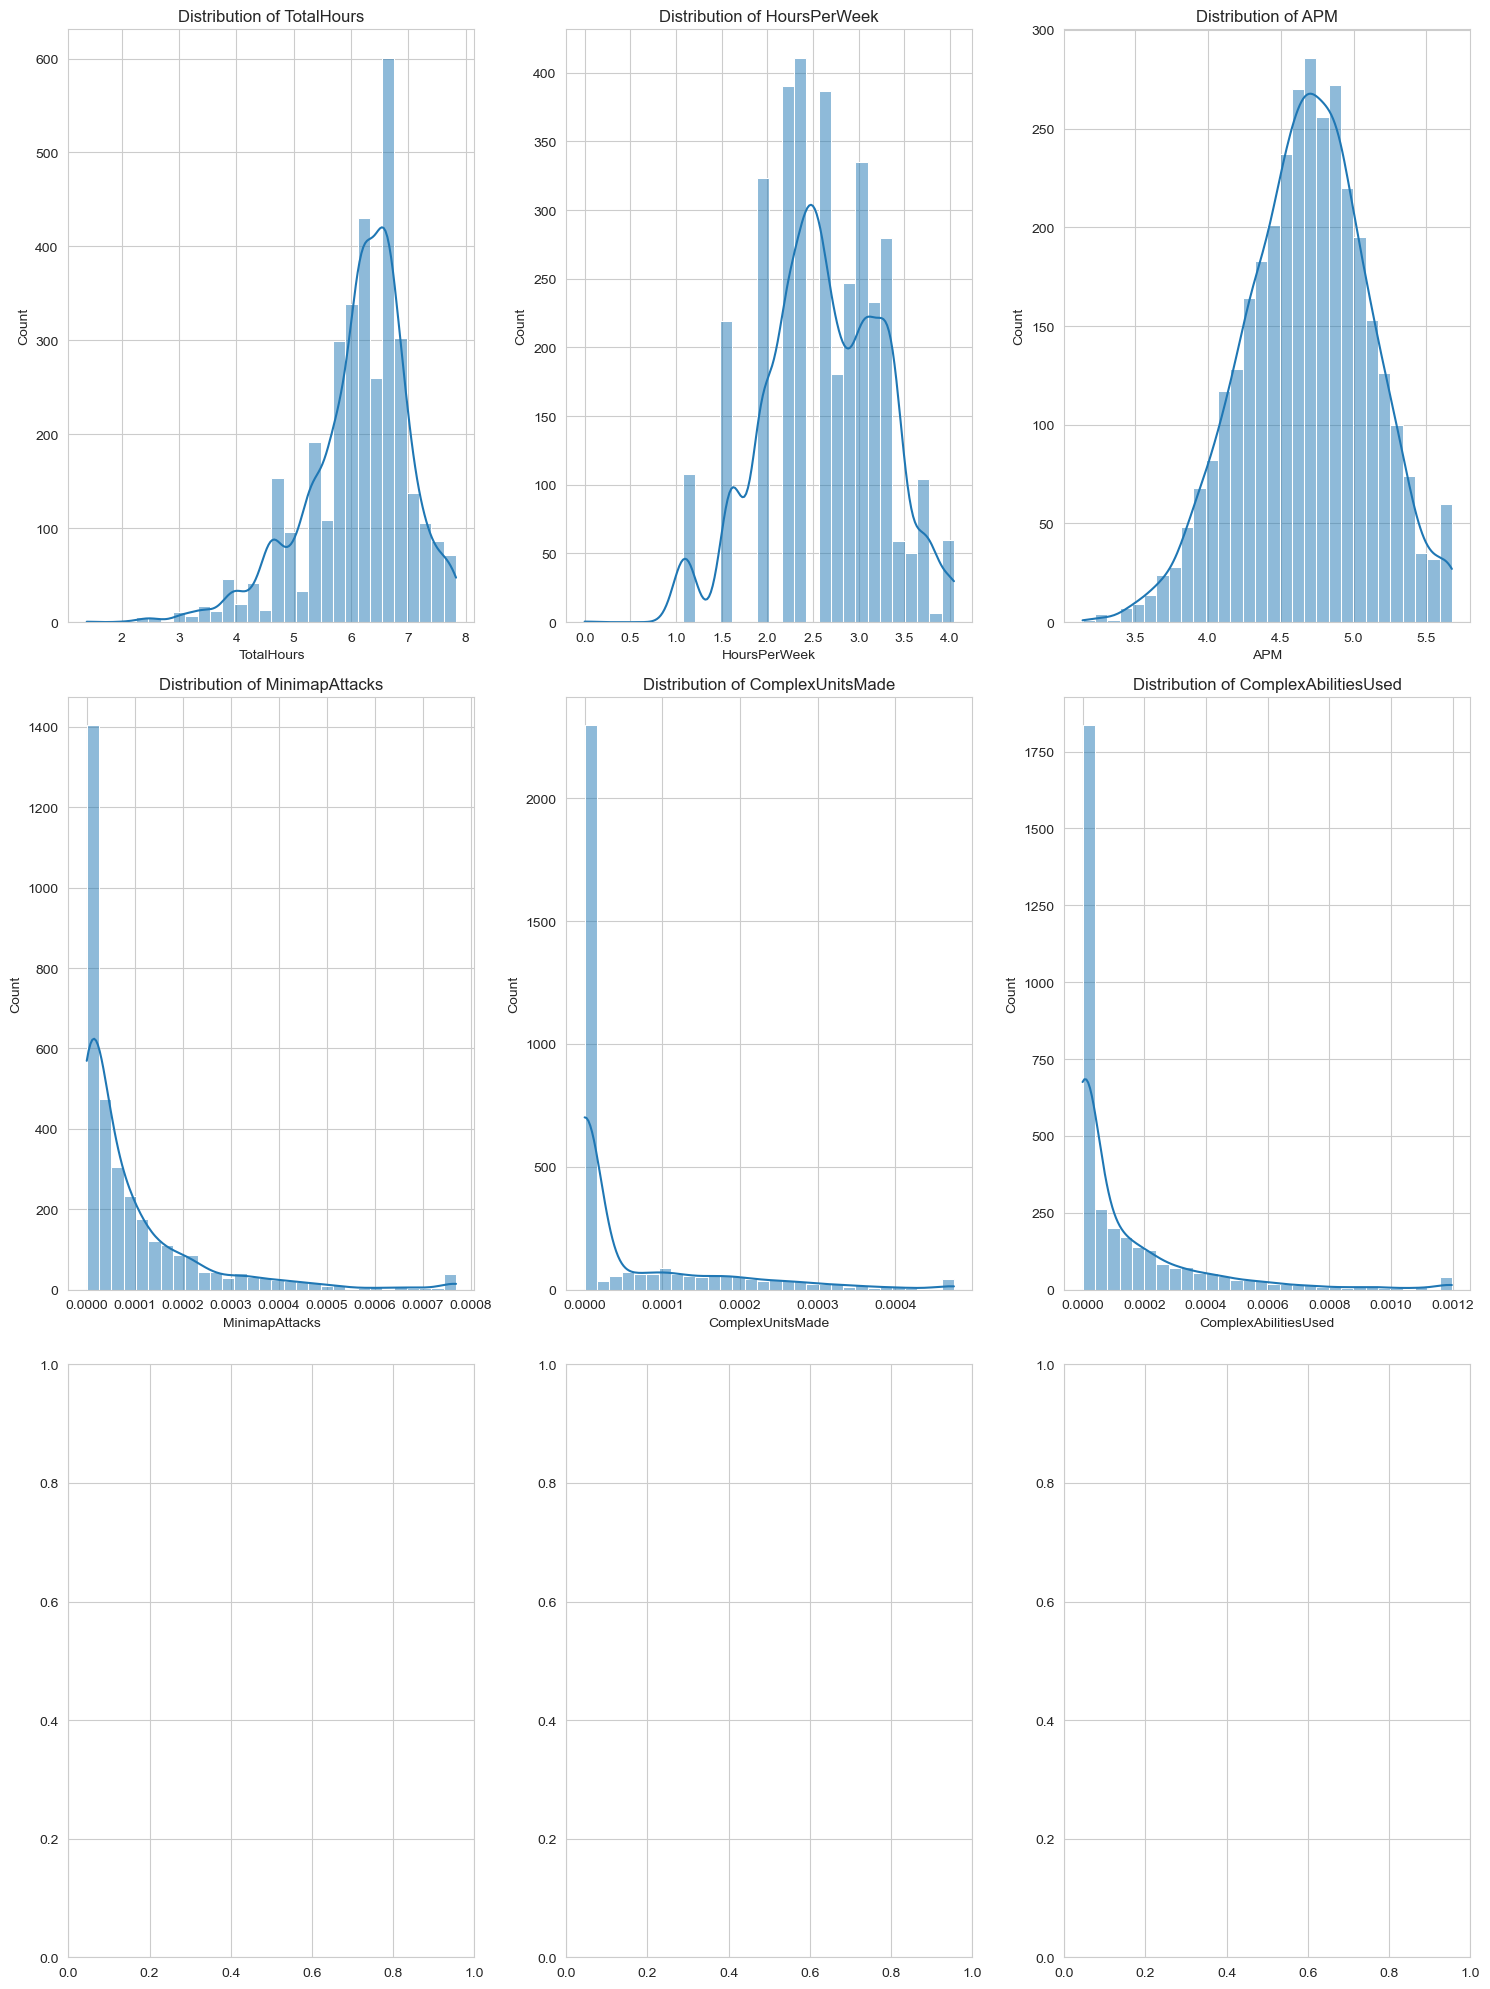

In [20]:
# List of cols transformed
norm_cols = ["TotalHours", "HoursPerWeek", "APM", "MinimapAttacks", "ComplexUnitsMade", "ComplexAbilitiesUsed"] 

# Create subplots
fig, axes = plt.subplots(len(norm_cols) // 3 + 1, 3, figsize=(15, 20))
axes = axes.flatten() 

# Plot histograms and boxplots
for i, col in enumerate(norm_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### Scaling
For features with extremely small values to ensure they are on a comparable scale

In [21]:
# Before Scaling
to_scale = [
    "SelectByHotkeys", "AssignToHotkeys", "UniqueHotkeys", "ComplexUnitsMade", 
    "ComplexAbilitiesUsed", "MinimapAttacks", "MinimapRightClicks", "NumberOfPACs"
]

print(df[to_scale].describe())

       SelectByHotkeys  AssignToHotkeys  UniqueHotkeys  ComplexUnitsMade  \
count      3395.000000      3395.000000    3395.000000       3395.000000   
mean          0.004299         0.000374       4.364654          0.000058   
std           0.005284         0.000225       2.360333          0.000107   
min           0.000000         0.000000       0.000000          0.000000   
25%           0.001258         0.000204       3.000000          0.000000   
50%           0.002500         0.000353       4.000000          0.000000   
75%           0.005133         0.000499       6.000000          0.000086   
max           0.043088         0.001752      10.000000          0.000476   

       ComplexAbilitiesUsed  MinimapAttacks  MinimapRightClicks  NumberOfPACs  
count           3395.000000     3395.000000         3395.000000   3395.000000  
mean               0.000136        0.000095            0.000387      0.003463  
std                0.000232        0.000141            0.000377      0.0009

In [22]:
### Normalize Small-Value Features 
scaler = MinMaxScaler()

scaled_cols = [
    "SelectByHotkeys", "AssignToHotkeys", "UniqueHotkeys", "ComplexUnitsMade", 
    "ComplexAbilitiesUsed", "MinimapAttacks", "MinimapRightClicks", "NumberOfPACs"
]  

df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

In [23]:
# Check after scaling
print(df[scaled_cols].describe())

       SelectByHotkeys  AssignToHotkeys  UniqueHotkeys  ComplexUnitsMade  \
count      3395.000000      3395.000000    3395.000000       3395.000000   
mean          0.099764         0.213205       0.436465          0.122965   
std           0.122642         0.128373       0.236033          0.224140   
min           0.000000         0.000000       0.000000          0.000000   
25%           0.029192         0.116554       0.300000          0.000000   
50%           0.058009         0.201216       0.400000          0.000000   
75%           0.119117         0.284692       0.600000          0.179867   
max           1.000000         1.000000       1.000000          1.000000   

       ComplexAbilitiesUsed  MinimapAttacks  MinimapRightClicks  NumberOfPACs  
count           3395.000000     3395.000000         3395.000000   3395.000000  
mean               0.113978        0.123441            0.095881      0.381792  
std                0.193854        0.183736            0.093298      0.1360

## Bivariate Analysis

### Heatmap

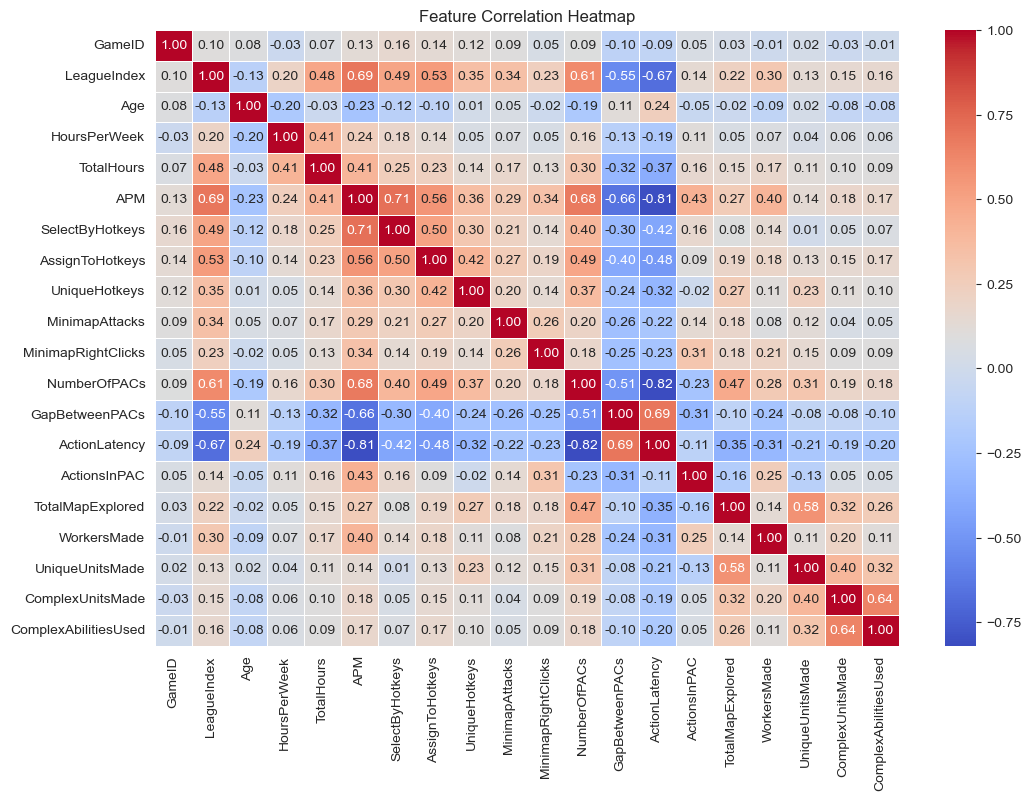

In [24]:
# Generates a correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

**Key Takeaways:**

1. **Strongest Correlations with LeagueIndex (|r| > 0.5):** 
- ActionLatency:Strong Negative correlation
- GapBetweenPACs: Strong Negative correlation 
- NumberOfPACs: Strong Postive correlation
- APM: Strong Postive correlation
- AssignToHotkeys: Positive correlation

2. **Moderate correlation with LeagueIndex (0.3 ≤ |r| ≤ 0.5):** 
- WorkersMade
- MinimapAttacks
- UniqueHotkeys
- SelectByHotkeys
- TotalHours

3. **Multicollinearity Risks:** 
- APM, SelectByHotKeys, ActionLatency, NumberOfPacs, GapBewteenPACs

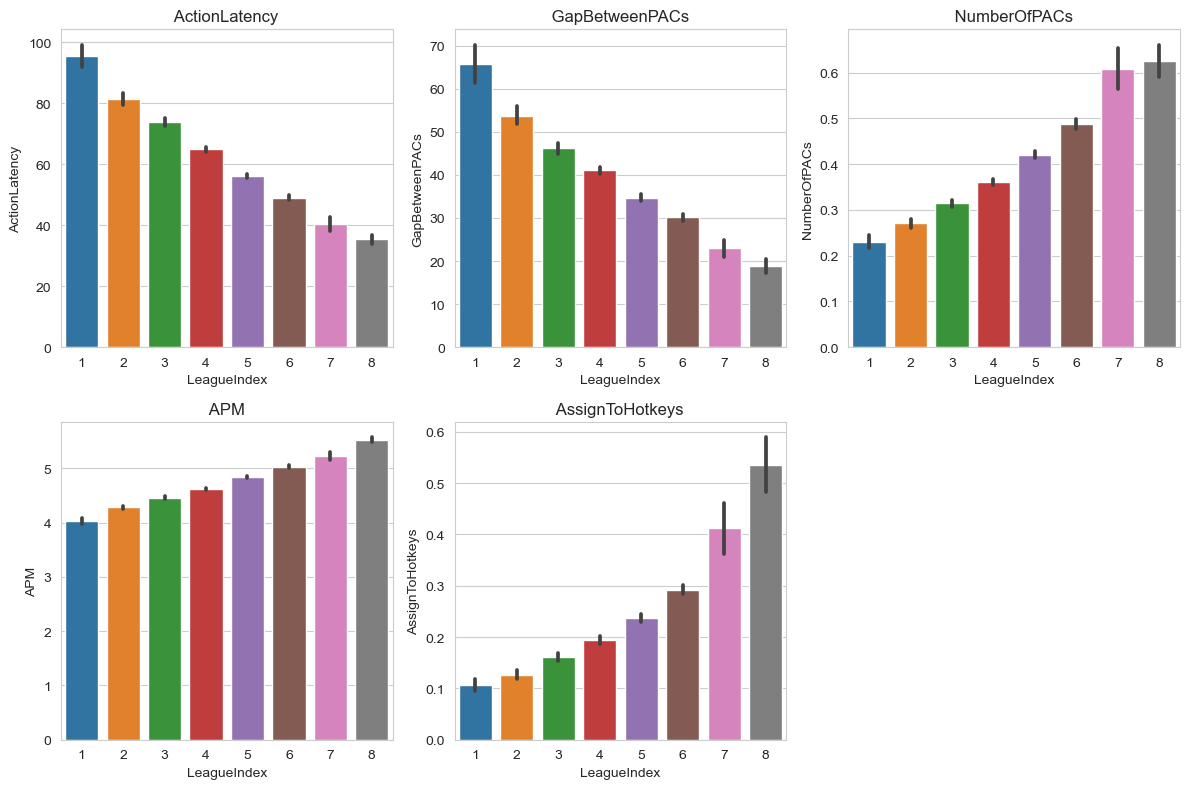

In [25]:
# Bar plots to show the Strong Correlations between features and Target variable
selected_features= ['ActionLatency', 'GapBetweenPACs', 'NumberOfPACs', 'APM', 'AssignToHotkeys']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x=df['LeagueIndex'], y= df[feature])
    plt.title(f" {feature} ")

plt.tight_layout()
plt.show()


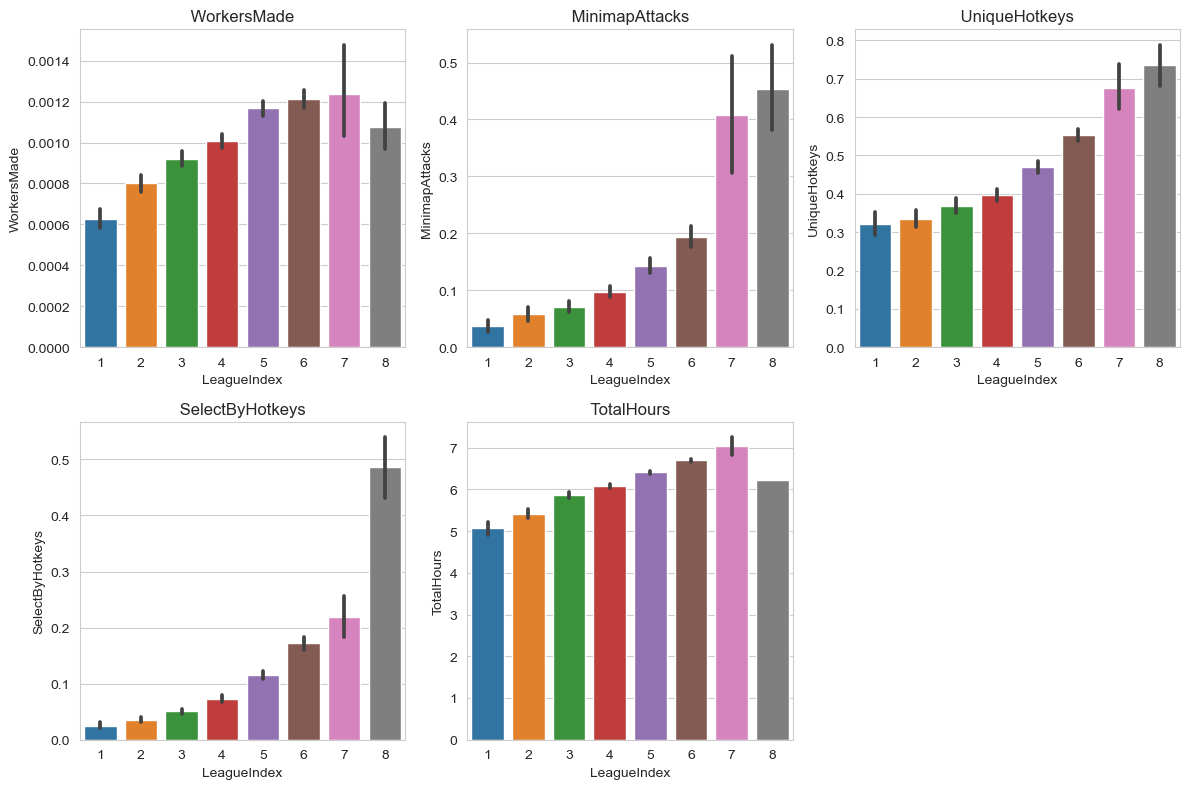

In [26]:
# Moderate Correlation barplot
selected_features= ['WorkersMade', 'MinimapAttacks', 'UniqueHotkeys', 'SelectByHotkeys', 'TotalHours']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x=df['LeagueIndex'], y= df[feature])
    plt.title(f" {feature} ")

plt.tight_layout()
plt.show()

## Multivariate Analysis

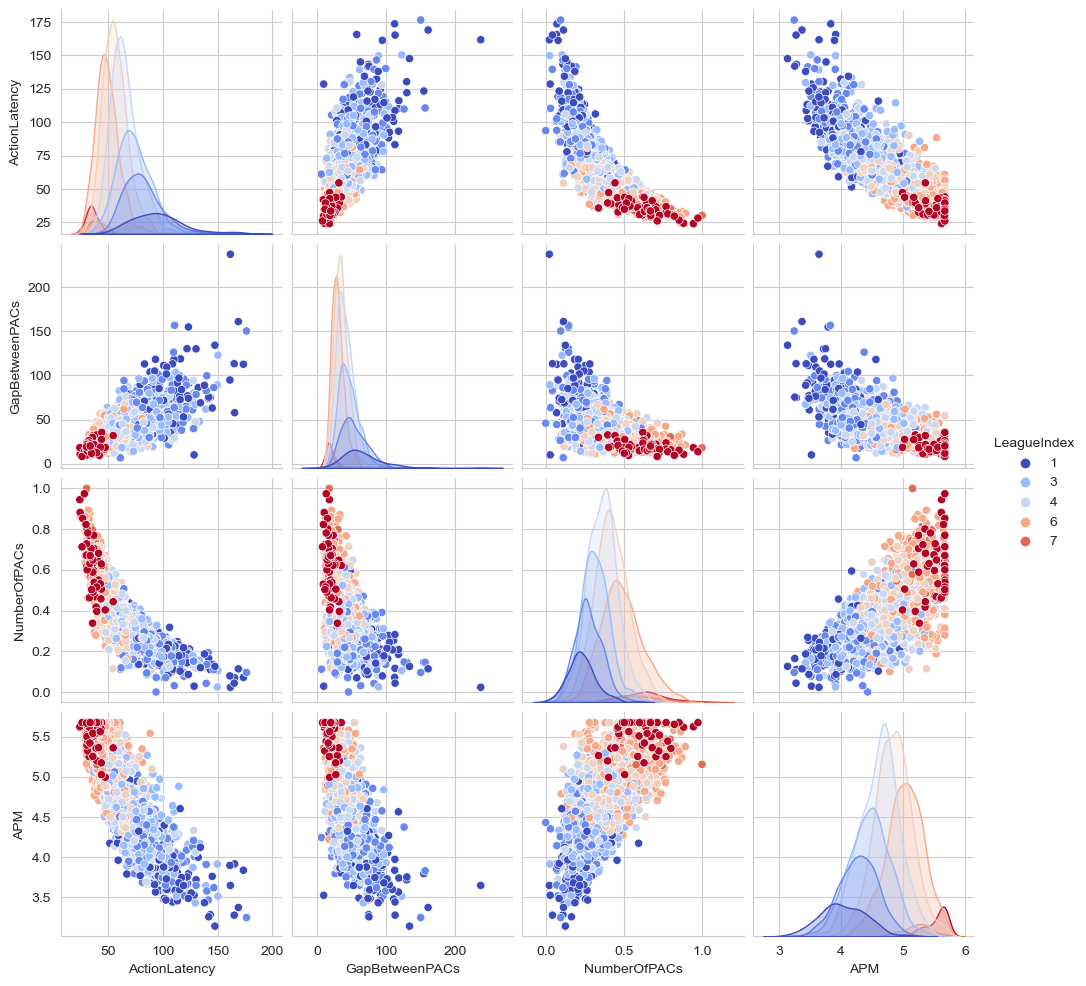

In [27]:
# Pair Plot on correlated features
selected_features = [
    "ActionLatency", "GapBetweenPACs", "NumberOfPACs", "APM", "LeagueIndex"
]

sns.pairplot(df[selected_features], hue="LeagueIndex", palette="coolwarm")
plt.show()

# 4. MODEL SELECTION & TRAINING

**To further improve the model:**
1. Feature Selection to find the most important predictors.
2. Balance the dataset (address rank imbalances).
3. Cross Validations and testing multiple models

## Feature Selection

In [30]:
# Compute Variance Inflation Factor (VIF)
X_selected = df.drop(columns=['LeagueIndex'])  # Exclude target variable
vif_data = pd.DataFrame()
vif_data["Feature"] = X_selected.columns
vif_data["VIF"] = [variance_inflation_factor(X_selected.values, i) for i in range(len(X_selected.columns))]

print(vif_data)

                 Feature         VIF
0                 GameID    4.355633
1                    Age   31.263144
2           HoursPerWeek   22.710712
3             TotalHours   68.822410
4                    APM  417.822834
5        SelectByHotkeys    3.067168
6        AssignToHotkeys    6.517709
7          UniqueHotkeys    5.910540
8         MinimapAttacks    1.743044
9     MinimapRightClicks    2.591659
10          NumberOfPACs   69.278194
11        GapBetweenPACs   14.941386
12         ActionLatency   45.397353
13          ActionsInPAC   50.770678
14      TotalMapExplored   19.161055
15           WorkersMade    6.304032
16       UniqueUnitsMade   22.436133
17      ComplexUnitsMade    2.468648
18  ComplexAbilitiesUsed    2.346412


In [31]:
# finding the correlations to the Target
correlations = df.corr()['LeagueIndex'].sort_values(ascending=False)
print(correlations)

LeagueIndex             1.000000
APM                     0.691186
NumberOfPACs            0.612192
AssignToHotkeys         0.531125
SelectByHotkeys         0.490599
TotalHours              0.482634
UniqueHotkeys           0.351213
MinimapAttacks          0.342247
WorkersMade             0.295643
MinimapRightClicks      0.233231
TotalMapExplored        0.221330
HoursPerWeek            0.198825
ComplexAbilitiesUsed    0.156473
ComplexUnitsMade        0.151702
ActionsInPAC            0.143121
UniqueUnitsMade         0.133508
GameID                  0.102601
Age                    -0.127288
GapBetweenPACs         -0.553246
ActionLatency          -0.673939
Name: LeagueIndex, dtype: float64


In [ ]:
# Selected features based on correlation and relevance
selected_features = [
    'NumberOfPACs', 'AssignToHotkeys', 'SelectByHotkeys', 
]

# Define target variable
target = "LeagueIndex"

# Define features and target variable
X = df[selected_features]  # Features
y = df[target]  # Target

# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Address Imbalances

In [ ]:
# Initialize SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Apply SMOTE to generate synthetic samples
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check new distribution
print(f"Before SMOTE - Training set class distribution:\n{y_train.value_counts()}")
print(f"After SMOTE - Training set class distribution:\n{y_train_resampled.value_counts()}")

## Building Classification Model using Random Forest
Although the scores were low, based on my findings and the problem question, I believe this model would be the best fit due to these factors:
1. Handling complex relationships: There are multiple complex features and relationships to determine a players rank.
2. Handling imbalanced classes: As shown before, there is a clear sample imbalance amongst LeagueIndex 7-8.
3. Handling feature scale: As seen in the dataset there are some features with a much lower scale compared to others.
4. Providing feature importance: This further helps with feature selection and understanding their relationship between ranks.

In [ ]:
# Train the model on balanced data
rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_smote.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_smote = rf_model_smote.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_smote)
classification_rep = classification_report(y_test, y_pred_smote, output_dict=True)

print("accuracy:", accuracy)

# Creating dataframe for classification report for better readability
report_df = pd.DataFrame(classification_rep).transpose()
print(report_df)

## Cross Validation on Models

## Logistic Regression Model

In [ ]:
# Train a Logistic Regression model
log_reg_Smote = LogisticRegression(max_iter=500, random_state=42)
log_reg_Smote.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_smote = log_reg_Smote.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_smote)
classification_rep = classification_report(y_test, y_pred_smote, output_dict=True)

print("accuracy:", accuracy)

# Creating dataframe for classification report for better readability
report_df = pd.DataFrame(classification_rep).transpose()
print(report_df)
